In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [2]:
df = yf.download("AAPL", start="2015-01-01", end="2025-01-01", auto_adjust=True)
df.columns = df.columns.get_level_values(0)

df['Close'] = df['Close'].squeeze()

[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
2015-01-02,24.192606,24.659508,23.754470,24.648443,212818400
2015-01-05,23.511061,24.042134,23.325186,23.962473,257142000
2015-01-06,23.513269,23.772167,23.152581,23.575228,263188400
2015-01-07,23.842981,23.942557,23.610636,23.721276,160423600
2015-01-08,24.759085,24.816618,24.053199,24.170479,237458000


In [4]:
df.shape

(2516, 5)

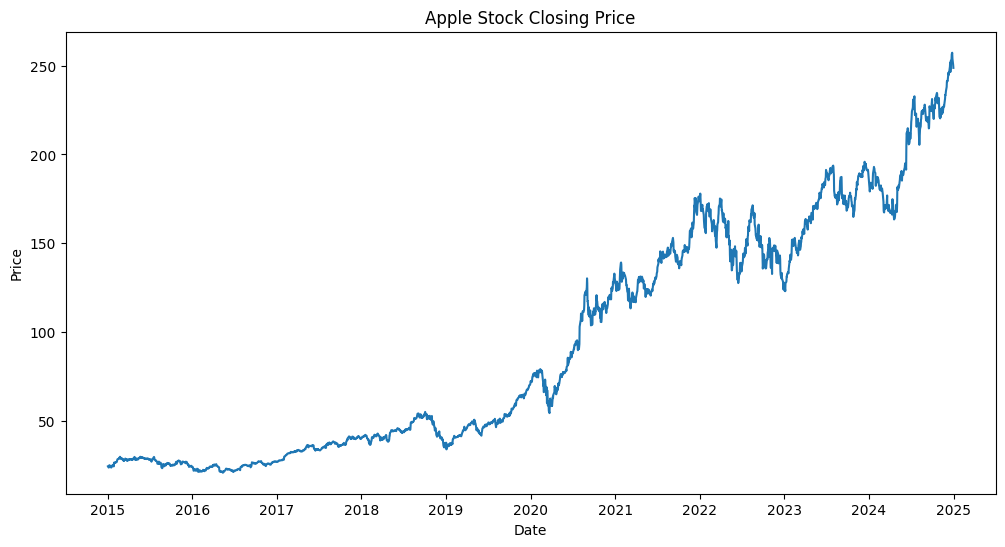

In [5]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'])

plt.title('Apple Stock Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')

plt.show()

In [6]:
data = df[['Close']]

In [7]:
scaler = MinMaxScaler(feature_range=(0,1))


In [8]:
scaled_data = scaler.fit_transform(data)

In [9]:
x_train = []
y_train = []

In [10]:
for i in range(60, len(scaled_data)):

    x_train.append(
        scaled_data[i-60:i, 0]
    )

    y_train.append(
        scaled_data[i, 0]
    )

x_train = np.array(x_train)
y_train = np.array(y_train)

In [11]:
x_train = np.reshape(
    x_train,
    (x_train.shape[0],
     x_train.shape[1],
     1)
)

print(x_train.shape)

(2456, 60, 1)


In [12]:
model =  Sequential()

In [13]:
model.add(LSTM(units =128,return_sequences = True, input_shape=(
    x_train.shape[1],
    1
)))

c:\Users\atish\OneDrive\Documents\Desktop\Stock\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.add(Dropout(0.2))


In [15]:
model.add(
    LSTM(
        units=128,
        return_sequences=False
    )
)

model.add(Dropout(0.2))


In [16]:
model.add(Dense(units=25))
model.add(Dense(units=1))

In [17]:
model.compile(
    optimizer='adam',
    loss ='mean_squared_error'
)

In [18]:
history = model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=10
)

Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - loss: 0.0065
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0012
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - loss: 9.0547e-04
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step - loss: 8.3589e-04
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step - loss: 8.5674e-04
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - loss: 9.3724e-04
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - loss: 6.4487e-04
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - loss: 7.3807e-04
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - loss: 7.4537e-04
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - loss: 5.8680e-04


In [19]:
model.save("stock_model.h5")

In [20]:
test_start = '2024-01-01'
test_end = '2025-01-01'

test_data = yf.download(
    'AAPL',
    start=test_start,
    end=test_end
)

actual_prices = test_data['Close'].values

[*********************100%***********************]  1 of 1 completed


In [21]:
total_dataset = pd.concat(
    (data['Close'], test_data['Close']),
    axis=0
)

In [22]:
model_inputs = total_dataset[
    len(total_dataset) - len(test_data) - 60:
].values

model_inputs = model_inputs.reshape(-1,1)

model_inputs = scaler.transform(model_inputs)

c:\Users\atish\OneDrive\Documents\Desktop\Stock\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [23]:
x_test = []

for i in range(60, len(model_inputs)):
    x_test.append(model_inputs[i-60:i, 0])

x_test = np.array(x_test)

In [24]:
x_test = np.reshape(
    x_test,
    (x_test.shape[0],
     x_test.shape[1],
     1)
)

In [25]:
predicted_prices = model.predict(x_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step


In [26]:
predicted_prices = scaler.inverse_transform(
    predicted_prices
)

In [30]:
actual_prices = actual_prices.flatten()
predicted_prices = predicted_prices.flatten()

min_length = min(
    len(actual_prices),
    len(predicted_prices)
)

actual_prices = actual_prices[-min_length:]
predicted_prices = predicted_prices[-min_length:]

print(actual_prices.shape)
print(predicted_prices.shape)

(252,)
(252,)


In [32]:
print(actual_prices[:10])
print(predicted_prices[:10])

print(actual_prices.shape)
print(predicted_prices.shape)


print(predicted_prices.min())
print(predicted_prices.max())

[183.56219482 182.1877594  179.87394714 179.15209961 183.48306274
 183.06777954 184.10603333 183.51274109 183.83903503 181.57469177]
[nan nan nan nan nan nan nan nan nan nan]
(252,)
(252,)
nan
nan


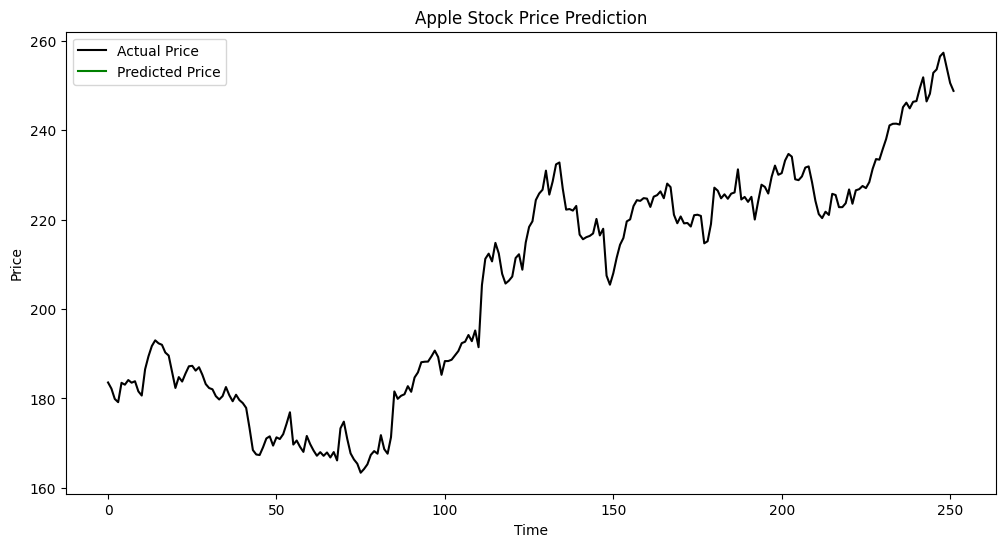

In [31]:
plt.figure(figsize=(12,6))

plt.plot(
    actual_prices,
    color='black',
    label='Actual Price'
)

plt.plot(
    predicted_prices,
    color='green',
    label='Predicted Price'
)

plt.title('Apple Stock Price Prediction')

plt.xlabel('Time')
plt.ylabel('Price')

plt.legend()

plt.show()

In [29]:
actual_prices = actual_prices.flatten()
predicted_prices = predicted_prices.flatten()

In [28]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        predicted_prices
    )
)

mae = mean_absolute_error(
    actual_prices,
    predicted_prices
)

print("RMSE:", rmse)
print("MAE:", mae)

ValueError: Found input variables with inconsistent numbers of samples: [252, 564]

In [ ]:
import ta

In [ ]:
# Moving Average
df['MA50'] = df['Close'].rolling(window=50).mean()

# RSI
df['RSI'] = ta.momentum.RSIIndicator(
    df['Close'].squeeze()
).rsi()

# MACD
macd = ta.trend.MACD(df['Close'].squeeze())

df['MACD'] = macd.macd()

# Volume Feature
df['Volume'] = df['Volume']

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.head()

Price,Close,High,Low,Open,Volume,MA50,RSI,MACD
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
2015-03-16,27.758123,27.758123,27.296045,27.520419,143497200,26.537694,51.177449,0.215347
2015-03-17,28.222425,28.284628,27.913632,27.969170,204092400,26.618290,56.042640,0.224620
2015-03-18,28.540106,28.693393,28.073583,28.213539,261083600,26.718871,59.049500,0.254668
2015-03-19,28.324614,28.713383,28.302399,28.602306,183238000,26.815098,56.239237,0.258118
2015-03-20,27.969175,28.524558,27.804782,28.491237,274780400,26.897622,51.855517,0.229524


In [ ]:
features = [
    'Close',
    'MA50',
    'RSI',
    'MACD',
    'Volume'
]

data = df[features]

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

x_train = []
y_train = []

for i in range(60, len(scaled_data)):

    # all features for past 60 days
    x_train.append(
        scaled_data[i-60:i]
    )

    # predict Close price only
    y_train.append(
        scaled_data[i, 0]
    )

x_train = np.array(x_train)
y_train = np.array(y_train)

print(x_train.shape)
print(y_train.shape)

(2407, 60, 5)
(2407,)


In [ ]:
model = Sequential()

# First LSTM Layer
model.add(
    LSTM(
        units=128,
        return_sequences=True,
        input_shape=(
            x_train.shape[1],
            x_train.shape[2]
        )
    )
)

model.add(Dropout(0.2))

# Second LSTM Layer
model.add(
    LSTM(
        units=128,
        return_sequences=False
    )
)

model.add(Dropout(0.2))

# Dense Layers
model.add(Dense(units=25))
model.add(Dense(units=1))

c:\Users\atish\OneDrive\Documents\Desktop\Stock\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32
)

Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 16s 112ms/step - loss: 0.0117
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - loss: 0.0015
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - loss: 0.0010
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.0011
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 110ms/step - loss: 0.0010
Epoch 6/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - loss: 9.7006e-04
Epoch 7/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 110ms/step - loss: 8.8532e-04
Epoch 8/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 8.8470e-04
Epoch 9/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - loss: 8.9573e-04
Epoch 10/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 7.9418e-04


In [ ]:
test_data = yf.download(
    'AAPL',
    start='2024-01-01',
    end='2025-01-01'
)

print(type(test_data['Close']))
print(test_data['Close'].shape)
print(test_data['Close'].head())

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
(252, 1)
Ticker            AAPL
2024-01-02  183.562180
2024-01-03  182.187759
2024-01-04  179.873947
2024-01-05  179.152100
2024-01-08  183.483078


In [ ]:
test_data['Close'] = pd.Series(
    test_data['Close'].values.flatten(),
    index=test_data.index
)
print(type(test_data['Close']))
print(test_data['Close'].shape)

<class 'pandas.core.frame.DataFrame'>
(252, 1)


In [ ]:
print(test_data.columns)

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [ ]:
test_data.columns = test_data.columns.get_level_values(0)

In [ ]:
# Moving Average
test_data['MA50'] = test_data['Close'].rolling(window=50).mean()

# RSI
test_data['RSI'] = ta.momentum.RSIIndicator(
    test_data['Close']
).rsi()

# MACD
macd = ta.trend.MACD(
    test_data['Close']
)

test_data['MACD'] = macd.macd()

# Remove NaN rows
test_data.dropna(inplace=True)

ValueError: Data must be 1-dimensional, got ndarray of shape (252, 1) instead

In [33]:
print(test_data.isnull().sum())

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64
